In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly as py
import plotly.graph_objs as go
from sklearn.cluster import KMeans
import warnings
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, RandomizedSearchCV, GridSearchCV, train_test_split

#from pandasql import sqldf
warnings.filterwarnings("ignore")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pwd
!ls /content/drive

/content
MyDrive  Othercomputers


In [4]:
!ls '/content/drive/MyDrive/FACULDADE/DADOS/notbooks/Student_performance_data _.csv'
caminho='/content/drive/MyDrive/FACULDADE/DADOS/notbooks/Student_performance_data _.csv'

'/content/drive/MyDrive/FACULDADE/DADOS/notbooks/Student_performance_data _.csv'


In [5]:
!pwd
path = caminho
df = pd.read_csv(path)
df.head()

/content


,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [6]:
#Looking for null values
df.isna().sum()

,0
StudentID,0
Age,0
Gender,0
Ethnicity,0
ParentalEducation,0
StudyTimeWeekly,0
Absences,0
Tutoring,0
ParentalSupport,0
Extracurricular,0


In [7]:
#Checking datatypes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


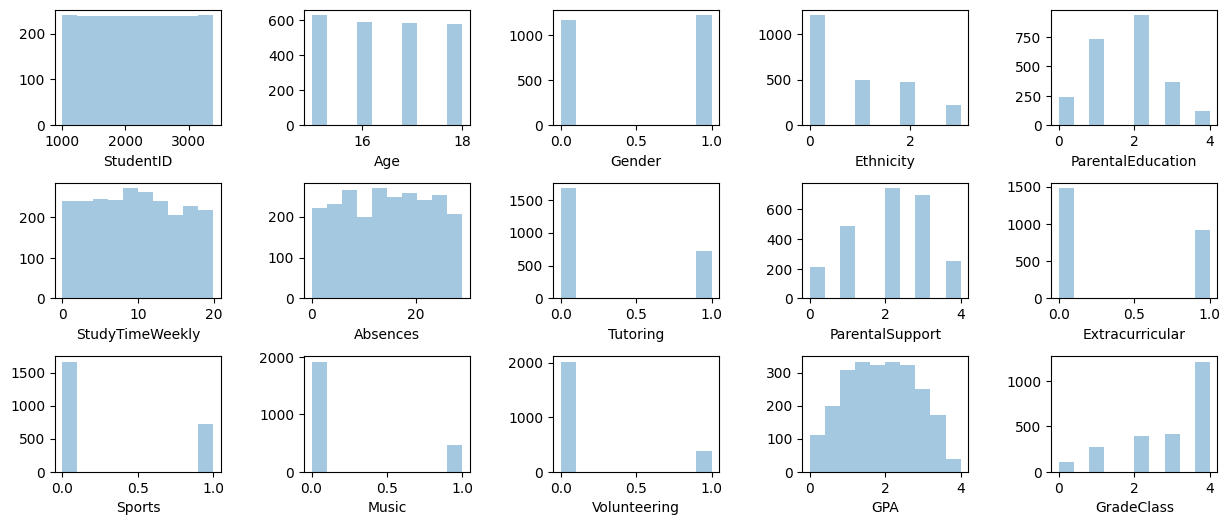

In [8]:
plt.figure(1 , figsize = (15 , 6))
feature_list = ['StudentID',	'Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA', 'GradeClass']
pos = 1
for i in feature_list:
    plt.subplot(3, 5, pos)
    plt.subplots_adjust(hspace = 0.5 , wspace = 0.5)
    sns.distplot(df[i], bins=10, kde = False)
    pos = pos + 1
plt.show()

In [9]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


#Defina Features categóricas e numéricas.

Regra usada:

*   Mais de 5 valores diferentes → numérica
*   5 ou menos → categórica

In [10]:
columns = list(df.columns)

categoric_columns = []
numeric_columns = []

for i in columns:
    if len(df[i].unique()) > 5:
        numeric_columns.append(i)
    else:
        categoric_columns.append(i)

numeric_columns = numeric_columns[1:]

print('Numerical features: ', numeric_columns)
print('Categorical features: ', categoric_columns)

Numerical features:  ['StudyTimeWeekly', 'Absences', 'GPA']
Categorical features:  ['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GradeClass']


In [11]:
# Converter colunas numéricas para float64
df[numeric_columns] = df[numeric_columns].astype('float64')

#Distribuição de Características Categóricas

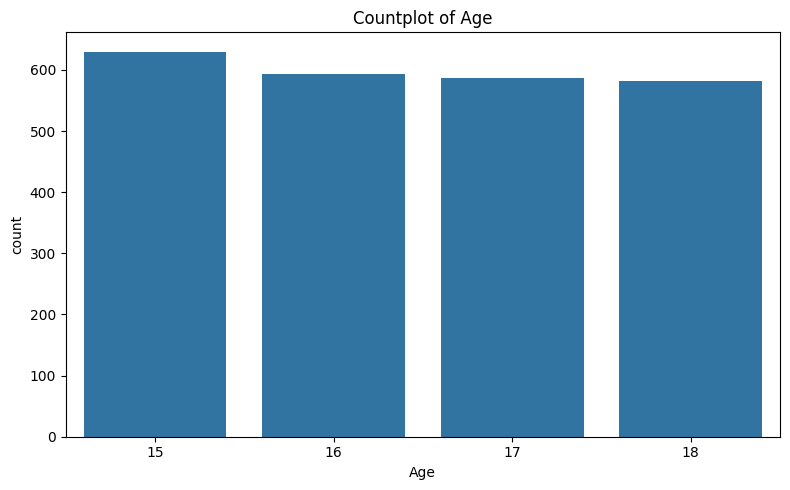

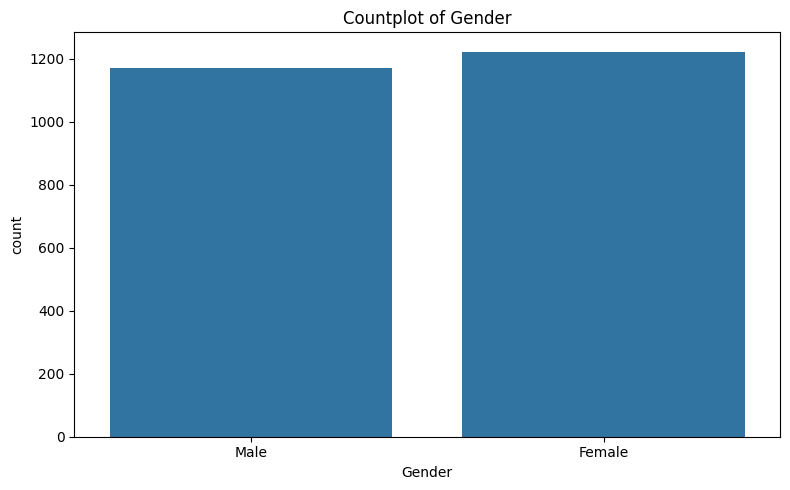

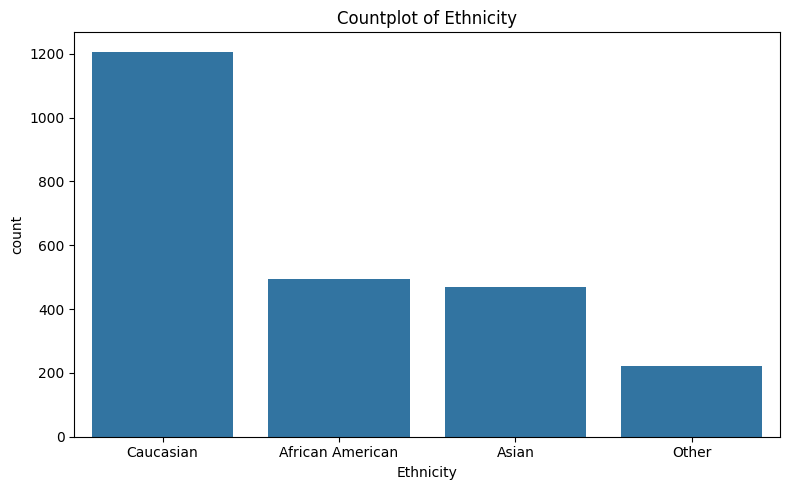

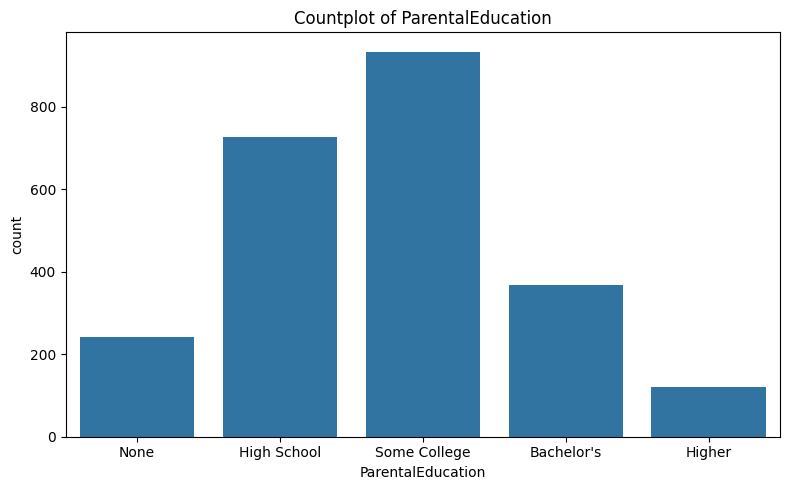

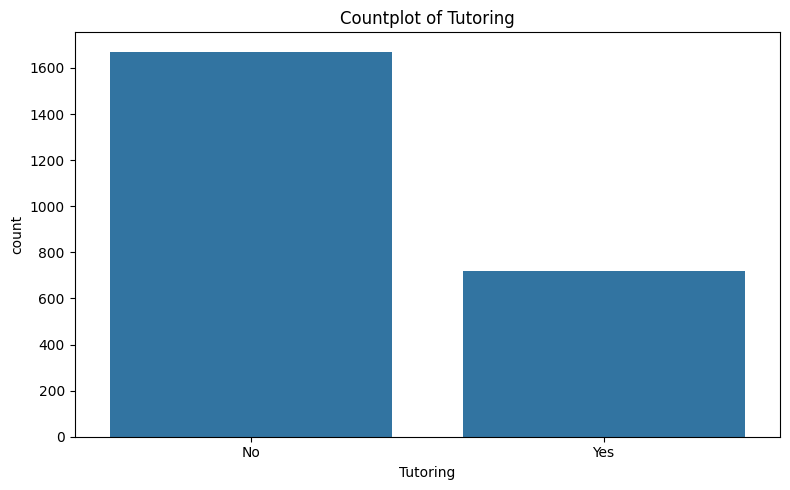

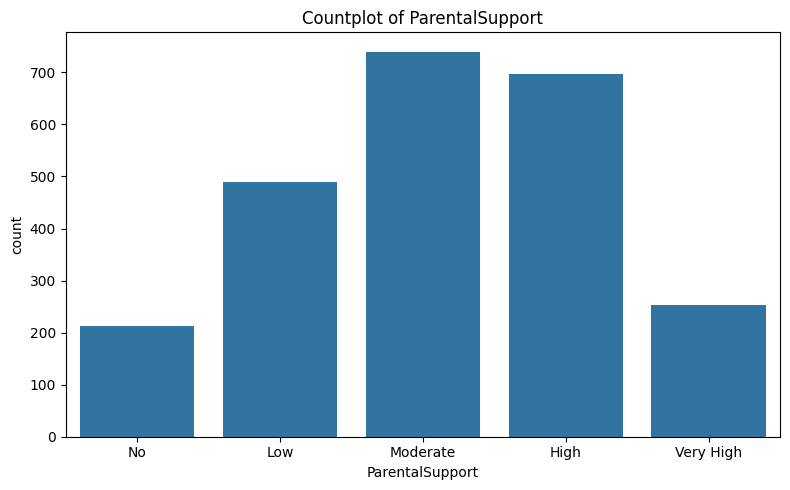

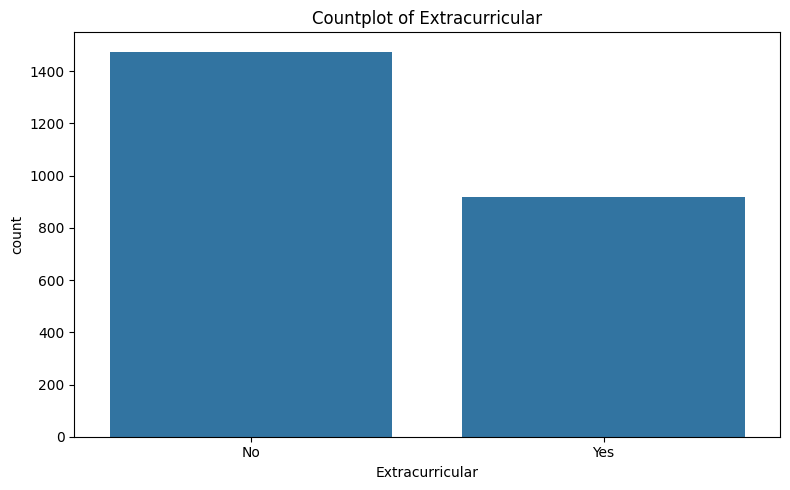

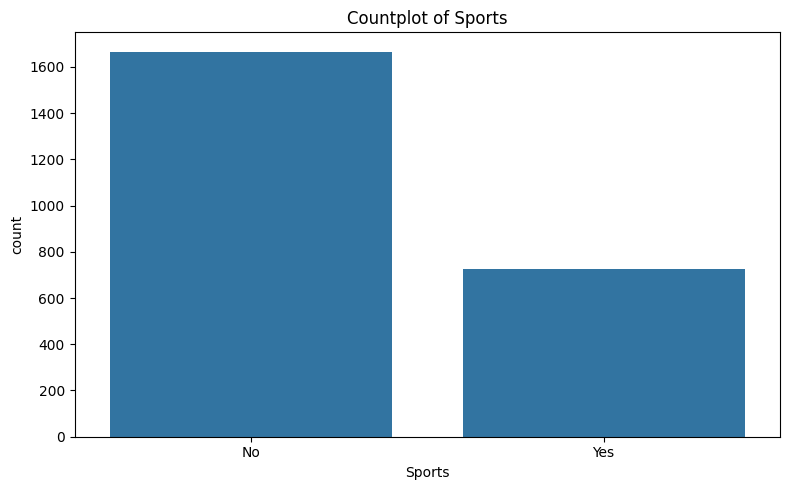

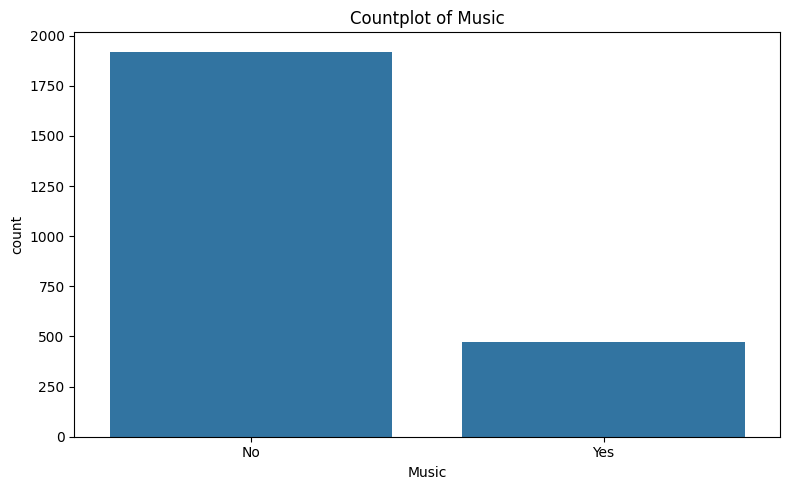

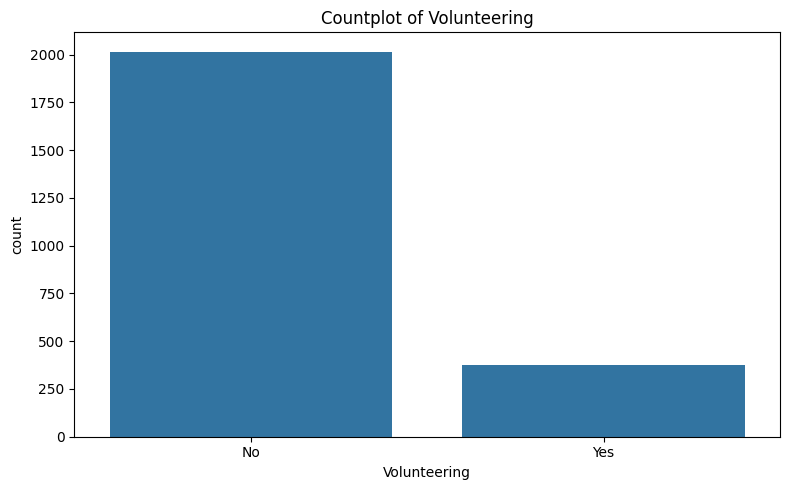

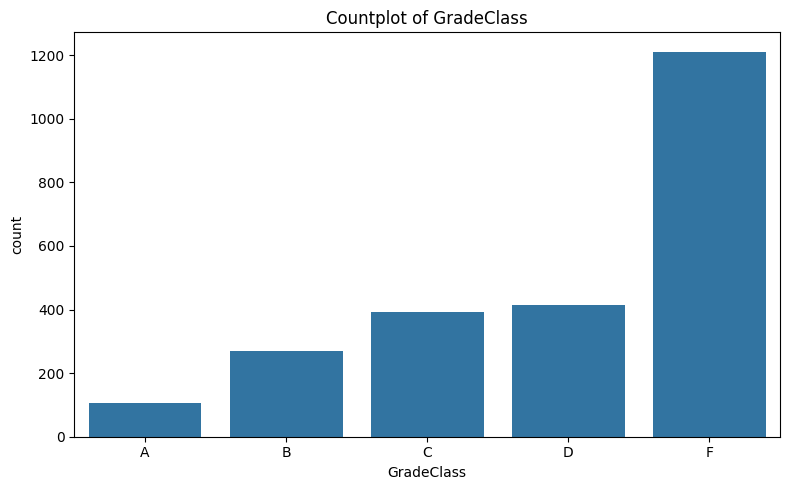

In [12]:
# Custom labels for the categorical columns
custom_labels = {
    'Ethnicity': ['Caucasian', 'African American', 'Asian', 'Other'],
    'Age': [15, 16, 17, 18],
    'ParentalEducation': ['None', 'High School', 'Some College', 'Bachelor\'s', 'Higher'],
    'Tutoring': ['No', 'Yes'],
    'ParentalSupport': ['No', 'Low', 'Moderate', 'High', 'Very High'],
    'Extracurricular': ['No', 'Yes'],
    'Sports': ['No', 'Yes'],
    'Music': ['No', 'Yes'],
    'Volunteering': ['No', 'Yes'],
    'Gender': ['Male', 'Female'],
    'GradeClass': ['A', 'B', 'C', 'D', 'F']
}

# Plot countplots for each categorical column
for column in categoric_columns:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=column)
    plt.title(f'Countplot of {column}')

    # Directly set custom labels
    labels = custom_labels[column]
    ticks = range(len(labels))
    plt.xticks(ticks=ticks, labels=labels)

    plt.tight_layout()
    plt.show()

In [13]:
display(df.head())

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7.0,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0.0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26.0,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14.0,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17.0,1,3,0,0,0,0,1.288061,4.0


In [14]:
df['GPA'] = df['GPA'].round(1)
df['GradeClass'] = df['GradeClass'].round(1)

display(df.head())

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7.0,1,2,0,0,1,0,2.9,2.0
1,1002,18,0,0,1,15.408756,0.0,0,1,0,0,0,0,3.0,1.0
2,1003,15,0,2,3,4.210570,26.0,0,2,0,0,0,0,0.1,4.0
3,1004,17,1,0,3,10.028829,14.0,0,3,1,0,0,0,2.1,3.0
4,1005,17,1,0,2,4.672495,17.0,1,3,0,0,0,0,1.3,4.0


#Matriz de correlação

Útil na etapa exploratória para entender a relação entre as variáveis do dataset.  

Ajuda a ver relações positivas e relações negativas e também a identificar redundâncias.

É bom usar pra análise inicial mas com ressalvas, principalmente no que diz respeito a variáveis categóricas.

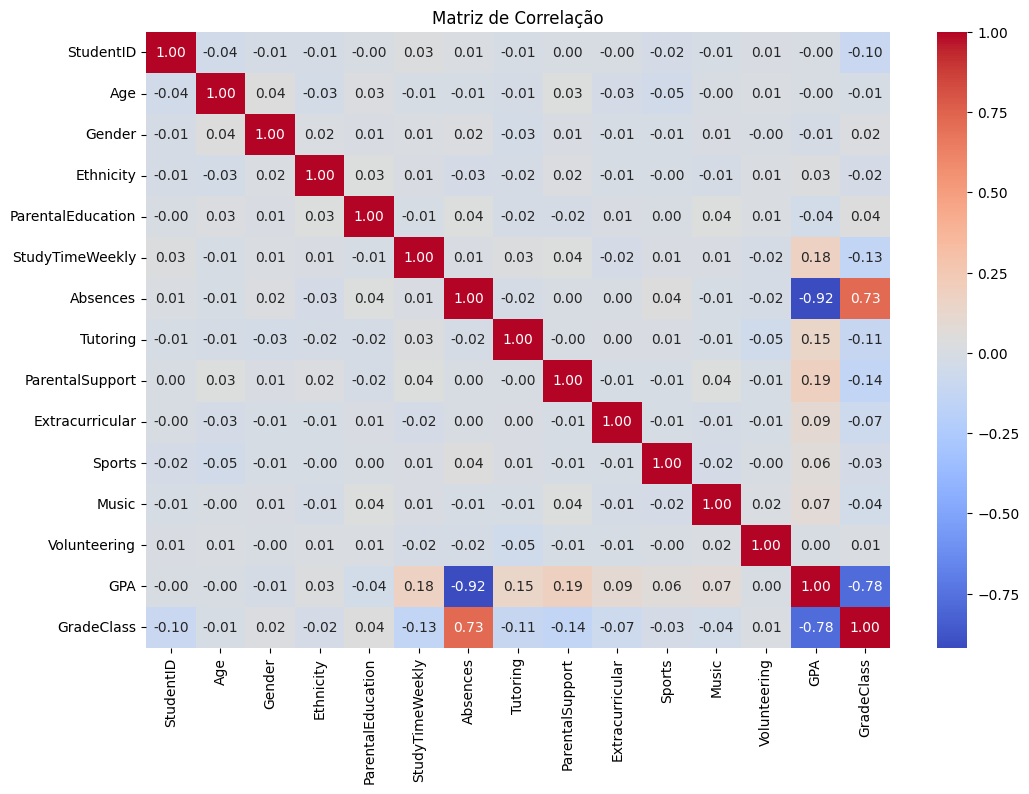

In [15]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

OBS: GradeClass é uma variável categórica convertida em valores numéricos para representar o desempenho acadêmico dos alunos com base no GPA (média geral ponderada). Nessa classificação, valores maiores representam desempenhos piores:

*   0 = A (GPA ≥ 3.5)
*   1 = B (3.0 ≤ GPA < 3.5)
*   2 = C (2.5 ≤ GPA < 3.0)
*   3 = D (2.0 ≤ GPA < 2.5)
*   4 = F (GPA < 2.0)

Dessa forma, a matriz de correlação mostra que, quanto maior a quantidade de faltas (Absences), menor tende a ser o GPA do aluno. Como a redução do GPA leva o aluno para categorias de desempenho piores, o valor de GradeClass aumenta.

Portanto:

* Mais faltas → menor GPA
* Menor GPA → pior classificação
* Pior classificação → maior valor em GradeClass

Resumo da relação:

Absences maior ⇒ GPA menor ⇒ GradeClass maior


#Feature importantes

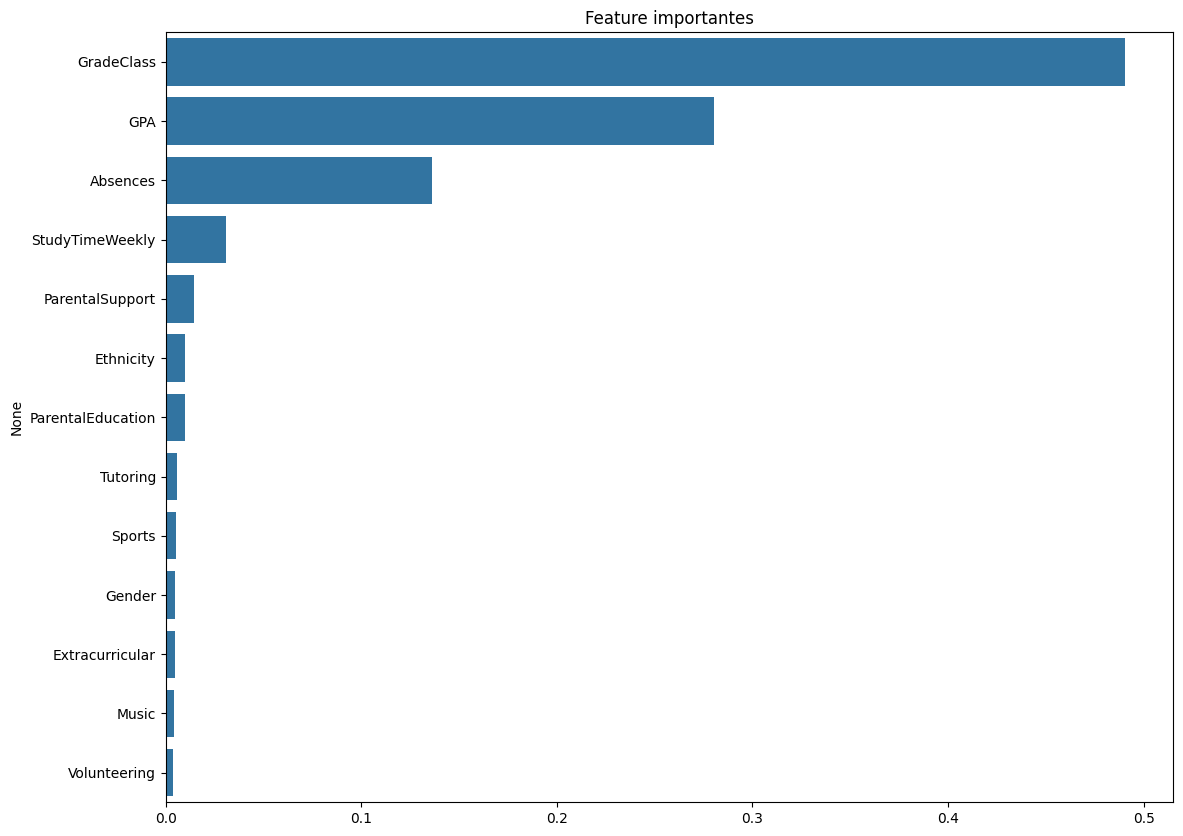

In [16]:
# Escolha da função desejada, no caso foi decidido 'GradeClass'
X = df.drop(columns=[ 'StudentID', 'Age'])
y = df['GradeClass']

# Dividir os dados em conjuntos de treino e teste (No caso, 80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

clf = RandomForestClassifier(random_state = 42)
clf = clf.fit(X, y)

fimp = pd.Series(data=clf.feature_importances_, index=X.columns).sort_values(ascending=False)


plt.figure(figsize=(13,10))
plt.title("Feature importantes")
ax = sns.barplot(y=fimp.index, x=fimp.values, orient='h')

#Remover colunas desncessárias

In [17]:
df_model = df.drop(columns=["Age","StudentID",  "Sports", "Music", "Volunteering", "Tutoring", "Extracurricular", "Gender"])
df_model.head()

,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,ParentalSupport,GPA,GradeClass
0,0,2,19.833723,7.0,2,2.9,2.0
1,0,1,15.408756,0.0,1,3.0,1.0
2,2,3,4.210570,26.0,2,0.1,4.0
3,0,3,10.028829,14.0,3,2.1,3.0
4,0,2,4.672495,17.0,3,1.3,4.0


#One-Hot Enconding

A variáveis Categóricas foram transformadas usando One-Hot Enconding que transforma uma variável categórica em uma variável binária.

Isso evita que o modelo interprete variáveis categóricas como numéricas.

In [18]:
df_model['GradeClass'] = df_model['GradeClass'].astype(int)

df_model = pd.get_dummies(df_model, columns=[  "Ethnicity", "ParentalEducation", "ParentalSupport"], prefix=[ "Ethnicity", "ParentalEducation", "ParentalSupport" ])



In [19]:
# rename_mapping = {
#     'GradeClass_0': '(GPA >= 3.5)',
#     'GradeClass_1': '(3.0 <= GPA < 3.5)',
#     'GradeClass_2': '(2.5 <= GPA < 3.0)',
#     'GradeClass_3': '(2.0 <= GPA < 2.5)',
#     'GradeClass_4': '(GPA < 2.0)',

#     'Ethnicity_0': 'Caucasian',
#     'Ethnicity_1': 'African American',
#     'Ethnicity_2': 'Asian',
#     'Ethnicity_3': 'Other',

#     'ParentalEducation_0': 'ParentalEd_None',
#     'ParentalEducation_1': 'ParentalEd_High School',
#     'ParentalEducation_2': 'ParentalEd_Some College',
#     'ParentalEducation_3': "ParentalEd_Bachelor's",
#     'ParentalEducation_4': 'ParentalEd_Higher',

#     'ParentalSupport_0': 'ParentalSup._None',
#     'ParentalSupport_1': 'ParentalSup._Low',
#     'ParentalSupport_2': 'ParentalSup._Moderate',
#     'ParentalSupport_3': 'ParentalSup._High',
#     'ParentalSupport_4': 'ParentalSup._Very High'
# }

# # Renomeando colunas
# df_model = df_model.rename(columns=rename_mapping)

# display(df_model.head())

In [20]:
rename_mapping = {

    'Ethnicity_0': 'Caucasian',
    'Ethnicity_1': 'African American',
    'Ethnicity_2': 'Asian',
    'Ethnicity_3': 'Other',

    'ParentalEducation_0': 'ParentalEd_None',
    'ParentalEducation_1': 'ParentalEd_High School',
    'ParentalEducation_2': 'ParentalEd_Some College',
    'ParentalEducation_3': "ParentalEd_Bachelor's",
    'ParentalEducation_4': 'ParentalEd_Higher',

    'ParentalSupport_0': 'ParentalSup._None',
    'ParentalSupport_1': 'ParentalSup._Low',
    'ParentalSupport_2': 'ParentalSup._Moderate',
    'ParentalSupport_3': 'ParentalSup._High',
    'ParentalSupport_4': 'ParentalSup._Very High'
}

# Renomeando colunas
df_model = df_model.rename(columns=rename_mapping)

display(df_model.head())

,StudyTimeWeekly,Absences,GPA,GradeClass,Caucasian,African American,Asian,Other,ParentalEd_None,ParentalEd_High School,ParentalEd_Some College,ParentalEd_Bachelor's,ParentalEd_Higher,ParentalSup._None,ParentalSup._Low,ParentalSup._Moderate,ParentalSup._High,ParentalSup._Very High
0,19.833723,7.0,2.9,2,True,False,False,False,False,False,True,False,False,False,False,True,False,False
1,15.408756,0.0,3.0,1,True,False,False,False,False,True,False,False,False,False,True,False,False,False
2,4.210570,26.0,0.1,4,False,False,True,False,False,False,False,True,False,False,False,True,False,False
3,10.028829,14.0,2.1,3,True,False,False,False,False,False,False,True,False,False,False,False,True,False
4,4.672495,17.0,1.3,4,True,False,False,False,False,False,True,False,False,False,False,False,True,False


#Distribuição de Características de interesse ('GPA' e 'GrandClass')

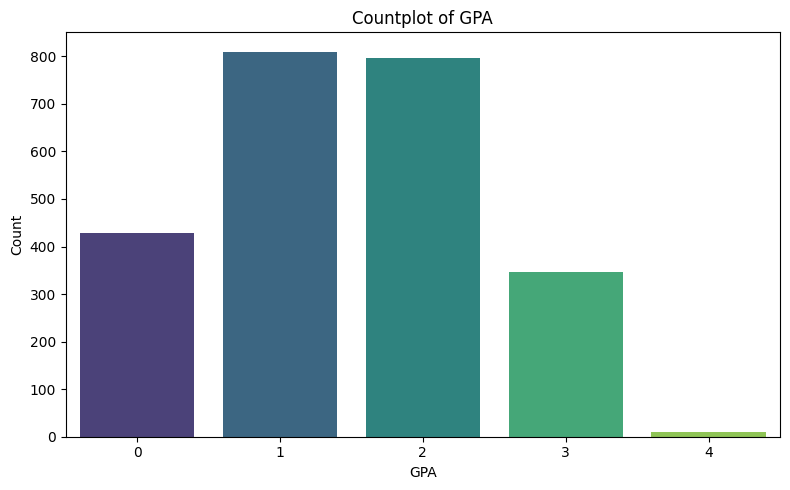

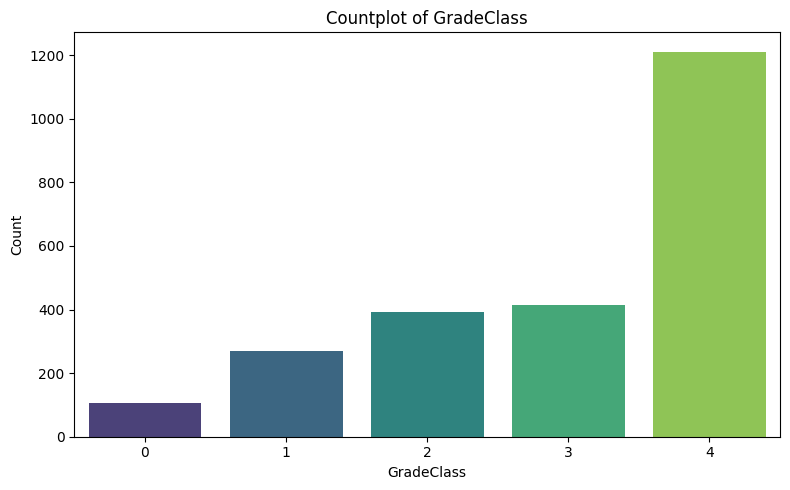

In [21]:
one_hot_encoded_cols = list(rename_mapping.values())

plotting_categorical_columns = ['GPA', 'GradeClass']

# Criando DataFrame apenas com as colunas desejadas
df_model_plot = df_model[plotting_categorical_columns].copy()

# Convertendo 'GPA' e 'Absences' para inteiro
df_model_plot['GPA'] = df_model_plot['GPA'].astype(int)

# Gerando os gráficos
for column in plotting_categorical_columns:
    plt.figure(figsize=(8, 5))

    sns.countplot(
        data=df_model_plot,
        x=column,
        palette='viridis'
    )

    plt.title(f'Countplot of {column}')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()





#Padronização

Etapa de extrema importância para colocar os dados na **mesma escala**.

Como o K-means funciona com distância entre os pontos, se os dados não seguem a mesma escala, um acaba tendo mais peso que o outro --> quanto maior o número, maior a distância

A padronização basicamente transforma o desvio padrão em uma unidade de medida, por isso seguem uma escala.

O StandardScaler transforma os dados de modo que cada variável passe a ter média igual a zero e desvio padrão igual a um.

**Ex.: um dado está a 2 "desvios padrão" acima da média, outro está a 5 "desvios padrão" abaixo da média.**

In [22]:
X = df_model.copy()

In [23]:
numerical_cols_to_scale = ['StudyTimeWeekly', 'Absences', 'GPA']
categorical_cols_unscaled = [col for col in X.columns if col not in numerical_cols_to_scale]

# Crie uma cópia para evitar modificar o X original no mesmo lugar.
X_processed = X.copy()

# Padronização apenas das colunas numéricas
scaler = StandardScaler()
X_processed[numerical_cols_to_scale] = scaler.fit_transform(X_processed[numerical_cols_to_scale])

# Combine as colunas numéricas padronizadas com as categóricas (one-hot encoded) não escaladas
X_scaled = X_processed[numerical_cols_to_scale + categorical_cols_unscaled]

# Visualizar
X_scaled.head()

,StudyTimeWeekly,Absences,GPA,GradeClass,Caucasian,African American,Asian,Other,ParentalEd_None,ParentalEd_High School,ParentalEd_Some College,ParentalEd_Bachelor's,ParentalEd_Higher,ParentalSup._None,ParentalSup._Low,ParentalSup._Moderate,ParentalSup._High,ParentalSup._Very High
0,1.780336,-0.890822,1.085325,2,True,False,False,False,False,False,True,False,False,False,False,True,False,False
1,0.997376,-1.717694,1.194528,1,True,False,False,False,False,True,False,False,False,False,True,False,False,False
2,-0.984045,1.353542,-1.972375,4,False,False,True,False,False,False,False,True,False,False,False,True,False,False
3,0.045445,-0.063951,0.211696,3,True,False,False,False,False,False,False,True,False,False,False,False,True,False
4,-0.902311,0.290422,-0.661932,4,True,False,False,False,False,False,True,False,False,False,False,False,True,False


#Método Elbow

Serve para descobrir quantos clusters (k) usar no K-means.

Esse método executa o k-means para diferentes números de clusters para calcular a inertia, que representa a soma das distâncias dos dados até o centroide de seus clusters

A tendência é a inertia diminuir com o aumento de clusters, até um ponto onde não faça muita diferença.

*   Inertia alta = grupos ruins, muito espalhados
*   Inertia baixa = grupos bons, bem agrupados


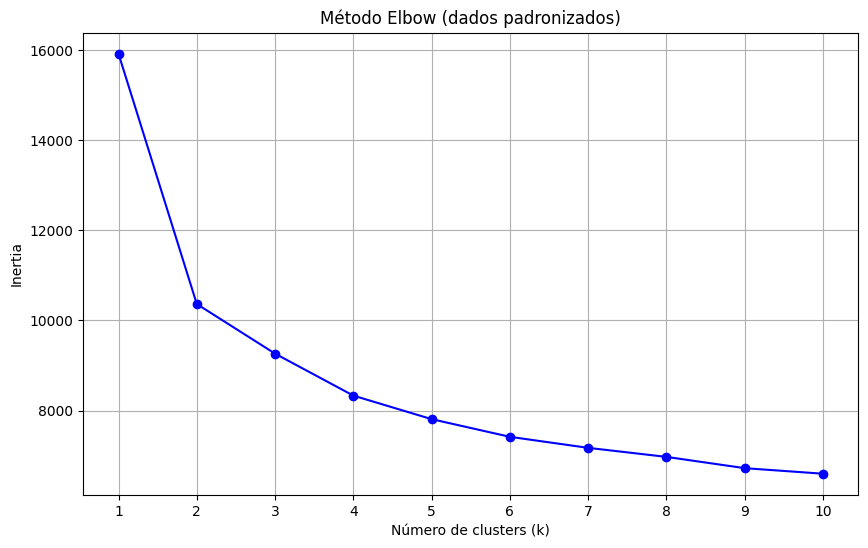

In [24]:
inertia = []
k = range(1, 11)

for i in k:
    kmeans = KMeans(n_clusters=i, random_state=0, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k, inertia, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inertia')
plt.title('Método Elbow (dados padronizados)')
plt.xticks(k)
plt.grid(True)
plt.show()

#Treinar K-means (4 Clusters)
Define k = 4 e agrupa os alunos em cada um desses clusters

Cada cluster representa um perfil de aluno.

(não é um ranking, só um agrupamento)

In [25]:
# kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
# clusters = kmeans.fit_predict(X_scaled)
# df["Cluster"] = clusters
# df_model["Cluster"] = clusters
# ## representa o cluster ao qual cada aluno foi atribuído
# df["Cluster"]

#Treinar K-means (3 Clusters)

Define k = 3 e agrupa os alunos em cada um desses clusters

Cada cluster representa um perfil de aluno.

(não é um ranking, só um agrupamento)

In [26]:
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
clusters = kmeans.fit_predict(X_scaled)
df["Cluster"] = clusters
df_model["Cluster"] = clusters
## representa o cluster ao qual cada aluno foi atribuído
df["Cluster"]

,Cluster
0,1
1,1
2,2
3,0
4,2
...,...
2387,1
2388,0
2389,0
2390,1


#Treinar K-means (2 Clusters)
Define k = 2 e agrupa os alunos em cada um desses clusters

Cada cluster representa um perfil de aluno.

(não é um ranking, só um agrupamento)

In [27]:
# kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
# clusters = kmeans.fit_predict(X_scaled)
# df["Cluster"] = clusters
# df_model["Cluster"] = clusters
# ## representa o cluster ao qual cada aluno foi atribuído
# df["Cluster"]

In [28]:
# quantidade de alunos por Cluster
df_model["Cluster"].value_counts()

,count
Cluster,
2,921
1,737
0,734


# Perfil Médio dos Cluster - Todas variáveis

In [29]:
# columns_to_analyze = [col for col in df.columns if col not in ['StudentID', 'Cluster', 'PCA1', 'PCA2']]
# cluster_summary = df.groupby("Cluster")[columns_to_analyze].mean()

# plt.figure(figsize=(16, 8)) # Aumentamos o tamanho das figuras para incluir mais variáveis.

# sns.heatmap(
#     cluster_summary,
#     annot=True,
#     cmap="RdYlGn",  # verde = bom, vermelho = ruim
#     fmt=".2f"
# )

# plt.title("Perfil médio dos clusters (todas as variáveis)")
# plt.xticks(rotation=45, ha='right')
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

# Perfil Médio dos Cluster - Todas variáveis que impactam no dataset (Random Forest)

In [30]:
# columns_to_analyze = ['GradeClass', 'GPA', 'Absences', 'StudyTimeWeekly', 'ParentalSupport', 'Ethnicity', 'ParentalEducation']
# cluster_summary = df.groupby("Cluster")[columns_to_analyze].mean()

# plt.figure(figsize=(16, 8))

# sns.heatmap(
#     cluster_summary,
#     annot=True,
#     cmap="RdYlGn",
#     fmt=".2f"
# )

# plt.title("Perfil médio dos clusters (variáveis de interesse)")
# plt.xticks(rotation=45, ha='right')
# plt.yticks(rotation=0)
# plt.tight_layout()
# plt.show()

# Perfil Médio dos Cluster - Variáveis Numéricas

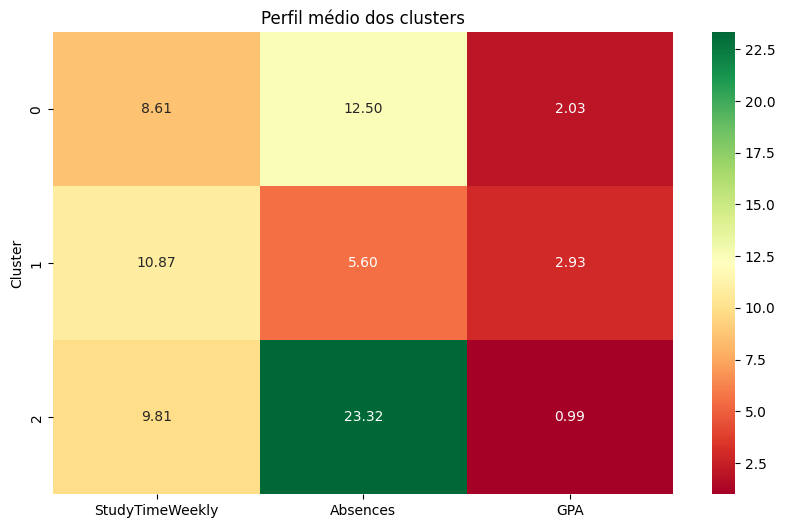

In [31]:
cluster_summary = df.groupby("Cluster")[[ "StudyTimeWeekly", "Absences", "GPA"]].mean()

plt.figure(figsize=(10, 6))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="RdYlGn",  # verde = bom, vermelho = ruim
    fmt=".2f"
)

plt.title("Perfil médio dos clusters")
plt.show()

## Variáveis "StudyTimeWeekly", "Absences", "GradeClass" (Obs: GradeClass é uma variável Categórica)

In [32]:
# cluster_summary = df.groupby("Cluster")[[ "StudyTimeWeekly", "Absences", "GradeClass"]].mean()

# plt.figure(figsize=(10, 6))

# sns.heatmap(
#     cluster_summary,
#     annot=True,
#     cmap="RdYlGn",  # verde = bom, vermelho = ruim
#     fmt=".2f"
# )

# plt.title("Perfil médio dos clusters")
# plt.show()

OBS: GradeClass é uma variável categórica convertida em valores numéricos para representar o desempenho acadêmico dos alunos com base no GPA (média geral ponderada). Nessa classificação, valores maiores representam desempenhos piores:

*   0 = A (GPA ≥ 3.5)
*   1 = B (3.0 ≤ GPA < 3.5)
*   2 = C (2.5 ≤ GPA < 3.0)
*   3 = D (2.0 ≤ GPA < 2.5)
*   4 = F (GPA < 2.0)

#PCA  - Análise de Componentes Principais

Pra uma melhor análise dos dados, foi aplicado o PCA para visualizar os dados de uma forma bidimensional, transformando as variáveis em 2 componentes matemáticos, onde estão concentrados as maiores variabilidades.

In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

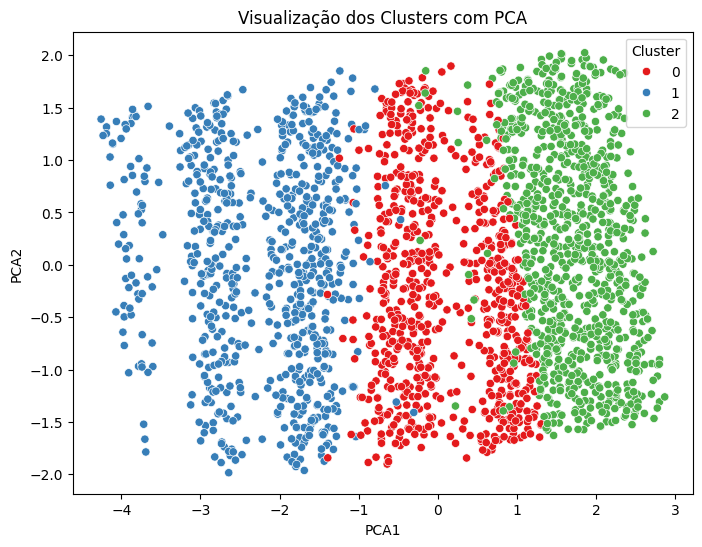

In [34]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x=df["PCA1"],
    y=df["PCA2"],
    hue=df["Cluster"],
    palette="Set1"
)

plt.title("Visualização dos Clusters com PCA")
plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.legend(title="Cluster")
plt.show()

# Silhoutte Score
Avalia o quão bons são os clusters

*   0.7 ~ 1.0	Excelente separação
*   0.5 ~ 0.7	Muito bom
*   0.3 ~ 0.5	Razoável
*   0.1 ~ 0.3	Fraco
*   ≈ 0	Clusters muito misturados
*   negativo	Clusterização ruim



In [35]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, df_model["Cluster"])
print("Silhouette Score:", score)

Silhouette Score: 0.16841264747646995


# Conclusão

A visualização dos clusters utilizando PCA demonstrou que existem diferenças entre os grupos de alunos, porém também há uma considerável sobreposição entre eles. Isso indica que os perfis encontrados pelo algoritmo K-Means não são completamente distintos.

O Silhouette Score obtido foi aproximadamente 0.15, valor considerado baixo, sugerindo uma separação moderada a fraca entre os clusters. Esse resultado indica que, embora existam padrões nos dados, os grupos apresentam características semelhantes entre si.

Mesmo com essa sobreposição, a clusterização ainda foi útil para identificar tendências gerais de comportamento acadêmico entre os alunos.